#import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Load the dataset

In [4]:
df = pd.read_csv("../data/bank-marketing.csv")



#Display first five records

In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,is_success
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#Understand Dataset Structure

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         45211 non-null  int64 
 1   job         45211 non-null  object
 2   marital     45211 non-null  object
 3   education   45211 non-null  object
 4   default     45211 non-null  object
 5   balance     45211 non-null  int64 
 6   housing     45211 non-null  object
 7   loan        45211 non-null  object
 8   contact     45211 non-null  object
 9   day         45211 non-null  int64 
 10  month       45211 non-null  object
 11  duration    45211 non-null  int64 
 12  campaign    45211 non-null  int64 
 13  pdays       45211 non-null  int64 
 14  previous    45211 non-null  int64 
 15  poutcome    45211 non-null  object
 16  is_success  45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#Check Dataset Shape

In [7]:
df.shape


(45211, 17)

#Display Column Names

In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'is_success'],
      dtype='object')

#Check Null Values

In [9]:
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
is_success    0
dtype: int64

#Check Total Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe

<bound method NDFrame.describe of        age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact 

#Convert Target Variable into Numerical Format


In [12]:
df["Target"] = df["is_success"].map({
    "no" : 0,
    "yes" : 1
})

#Check Target Variable Distribution

In [13]:
df['Target'].value_counts()

Target
0    39922
1     5289
Name: count, dtype: int64

#Drop Original Target Column

In [15]:
df.drop(columns=["is_success"], inplace=True)


#Import ScorecardPy Library for WOE and IV

In [16]:
import scorecardpy as sc

d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#Calculate Weight Of Evidence

In [ ]:
bins = sc.woebin(df, y = "Target")

#Apply WOE Transformation

In [21]:
df_woe = sc.woebin_ply(df, bins)
df_woe.head()

[INFO] converting into woe values ...


,Target,loan_woe,balance_woe,month_woe,job_woe,day_woe,pdays_woe,previous_woe,marital_woe,campaign_woe,contact_woe,duration_woe,poutcome_woe,age_woe,housing_woe,default_woe,education_woe
0,0,0.089551,0.393979,-0.609306,0.203273,-0.14349,-0.272624,-0.273276,-0.162282,0.25478,-1.138508,0.281430,-0.272775,0.817062,-0.462531,0.0,0.273337
1,0,0.089551,-0.315435,-0.609306,-0.013345,-0.14349,-0.272624,-0.273276,0.282706,0.25478,-1.138508,-0.948263,-0.272775,-0.270239,-0.462531,0.0,-0.115256
2,0,-0.615395,-0.315435,-0.609306,-0.437552,-0.14349,-0.272624,-0.273276,-0.162282,0.25478,-1.138508,-2.704673,-0.272775,-0.096009,-0.462531,0.0,-0.115256
3,0,0.089551,0.156433,-0.609306,-0.437552,-0.14349,-0.272624,-0.273276,-0.162282,0.25478,-1.138508,-0.948263,-0.272775,-0.270239,-0.462531,0.0,0.273337
4,0,0.089551,-0.315435,-0.609306,-0.013345,-0.14349,-0.272624,-0.273276,0.282706,0.25478,-1.138508,-0.948263,-0.272775,-0.096009,0.414428,0.0,0.273337


#Display Information Values (IV) of Features

In [22]:
iv_df = sc.iv(df, y="Target")
iv_df

,variable,info_value
12,duration,1.667240
8,balance,0.904982
2,pdays,0.550570
13,poutcome,0.514609
9,month,0.436131
4,contact,0.300396
15,previous,0.231714
14,age,0.226495
5,housing,0.188681
1,job,0.155697


#Import library for VIF Calculation

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Select Independent variable

In [24]:
X = df_woe.drop(columns=["Target"])

#Calculate VIF For Each Feature

In [25]:
vif = pd.DataFrame()

vif["feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

d:\anaconda3\envs\ds311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
0,loan_woe,1.035214
1,balance_woe,1.072839
2,month_woe,1.281454
3,job_woe,1.300422
4,day_woe,1.022862
5,pdays_woe,3.899609
6,previous_woe,5.063570
7,marital_woe,1.058407
8,campaign_woe,1.066470
9,contact_woe,1.336898


#Remove Weak feature

In [26]:
X = X.drop(columns=["default_woe"])
y = df_woe["Target"]

#Split Data Into Training and Testing Sets

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

#Import Logistic Regression and GridSearchCV

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Create Logistic Regression Model

In [29]:
log_model = LogisticRegression(max_iter=1000)

#Define Hyperparameter Grid

In [30]:
param_grid = {
    "C" : [0.01, 0.1, 1, 10] ,
    "solver" : ["liblinear", "lbfgs"]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [31]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv = 5,
    scoring="f1",
    n_jobs = -1
)

#Train Logistic Regression Model

In [32]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

#Display Best Hyperparameters

In [34]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'C': 10, 'solver': 'lbfgs'}
Best F1 Score : 0.38579748030362504


#Predict Target Values on Test Data

In [35]:
y_pred = grid_search.predict(X_test)

#Import Model Evaluation Metrics

In [36]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

#Evaluate Logistic Regression Model

In [37]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8925948863133681
Precision : 0.5764872521246459
Recall : 0.30786686838124055
F1 : 0.40138067061143984


#Display Confusion Matrix

In [38]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[9682  299]
 [ 915  407]]


#Display Classification Report

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      9981
           1       0.58      0.31      0.40      1322

    accuracy                           0.89     11303
   macro avg       0.75      0.64      0.67     11303
weighted avg       0.87      0.89      0.88     11303



#Import Decision Tree and GridSearchCV

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#Create Decision Tree Classifier

In [41]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

#Define Hyperparameters for Decision Tree

In [42]:
param_grid = {
    "criterion" : ["gini", "entropy"],
    "max_depth" : [3, 5, 7, 10],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [43]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv = 5,
    scoring="f1",
    n_jobs=-1
)

#Train Decision Tree Model

In [44]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

#Display Best Hyperparameters

In [45]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best F1 Score : 0.46595661512746733


#Predict Target Values on Test Dataset

In [46]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [47]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

#Evaluate Decision Tree Model

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8929487746615943
Precision : 0.5590717299578059
Recall : 0.4009077155824508
F1 : 0.4669603524229075


#Display Confusion Matrix

In [49]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[9563  418]
 [ 792  530]]


#Display Classification Report

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      9981
           1       0.56      0.40      0.47      1322

    accuracy                           0.89     11303
   macro avg       0.74      0.68      0.70     11303
weighted avg       0.88      0.89      0.89     11303



#Display Feature Importance

In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

         Feature  Importance
10  duration_woe    0.392449
11  poutcome_woe    0.135331
2      month_woe    0.127476
4        day_woe    0.079264
13   housing_woe    0.064326
9    contact_woe    0.052544
1    balance_woe    0.027195
12       age_woe    0.026525
3        job_woe    0.018029
5      pdays_woe    0.017274


### This tells us which features contributed the most to the Decision Tree.

#Visualize Decision Tree

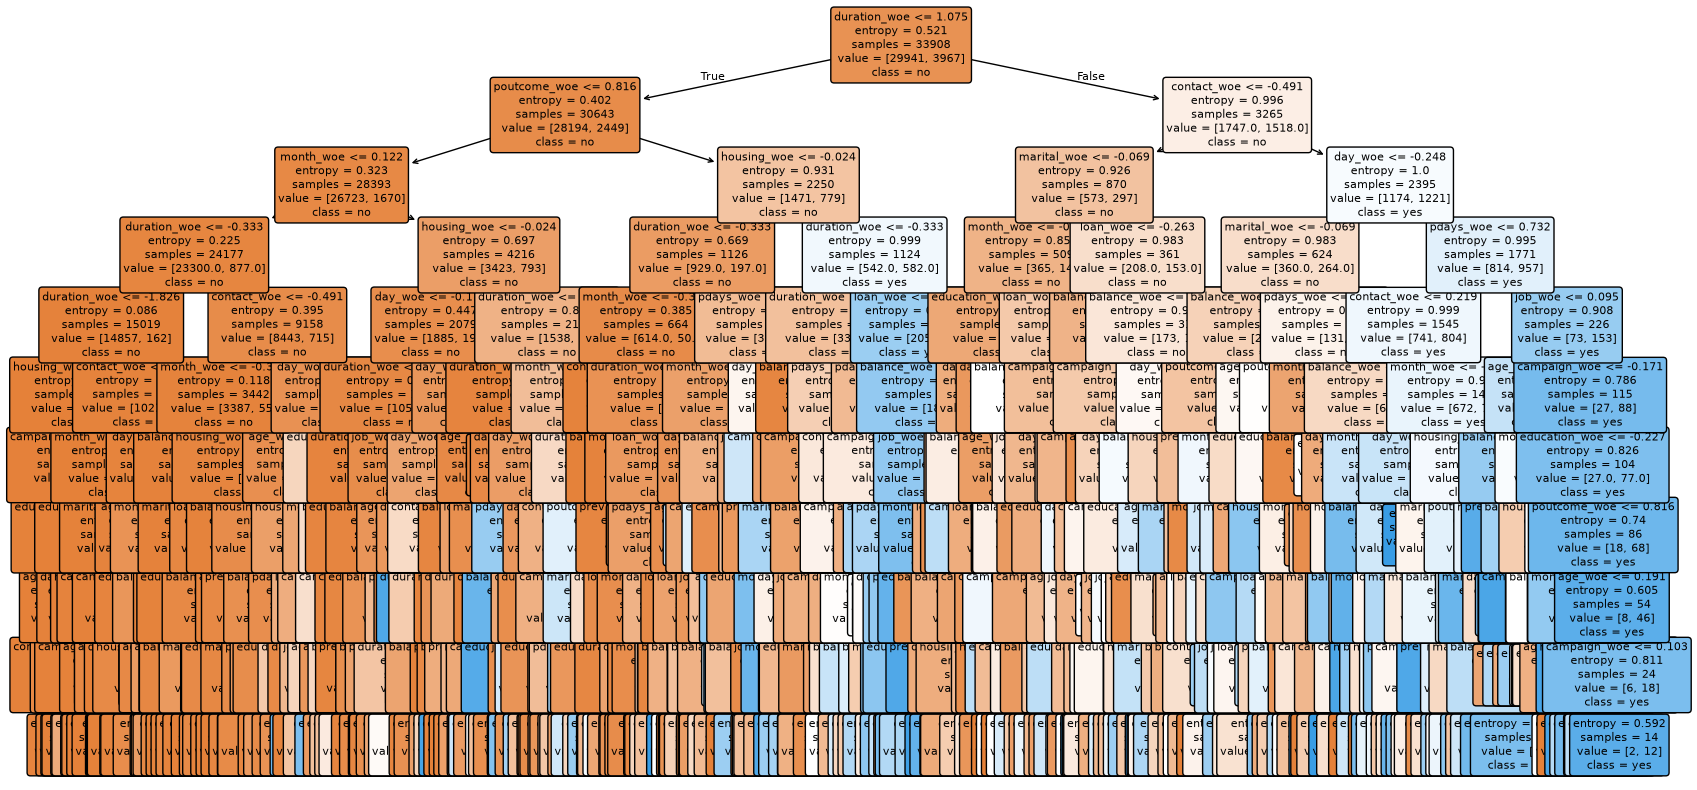

In [53]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    grid_search.best_estimator_,
    feature_names = X.columns,
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

# Final Conclusion


## Model Comparison

Both models achieved similar accuracy, but I selected the Decision Tree because it had a better Recall and F1-Score, indicating better performance in identifying positive instances. Logistic Regression had slightly higher Precision, but it missed more actual positive cases. Therefore, Decision Tree provided a better overall balance for this classification problem.